# Figure 2 Distribution Plots

This notebook generates report-ready distribution plots for:

- (a) Sequence length distribution
- (b) `delta_prev_seconds` distribution
- (c) `delta_start_seconds` distribution

The notebook uses the final processed dataset for Stage 3:

- `data/processed/bpi2012_complete_only_stage3_v2/events_encoded_time_features.csv`

Output figures are saved under `outputs/report_figures/`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bpi2012_complete_only_stage3_v2" / "events_encoded_time_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "report_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

font_candidates = [
    Path("C:/Windows/Fonts/malgun.ttf"),
    Path("C:/Windows/Fonts/malgunbd.ttf"),
    Path("C:/Windows/Fonts/gulim.ttc"),
    Path("C:/Windows/Fonts/batang.ttc"),
]
for font_path in font_candidates:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ["Malgun Gothic", "Gulim", "Batang", "NanumGothic", "AppleGothic", "DejaVu Sans"]
selected_font = next((font for font in preferred_fonts if font in available_fonts), "DejaVu Sans")

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": selected_font,
    "axes.unicode_minus": False,
})

print(f"Using font: {selected_font}")
DATA_PATH


Using font: Malgun Gothic


WindowsPath('C:/Users/hyewoo choi/Documents/99. 대학원/0. 논문/git/time-aware-behavior-prediction/data/processed/bpi2012_complete_only_stage3_v2/events_encoded_time_features.csv')

In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = [
    "case_id",
    "event_idx",
    "delta_prev_seconds",
    "delta_start_seconds",
]
missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

case_lengths = df.groupby("case_id").size()

summary = {
    "num_events": int(len(df)),
    "num_cases": int(df["case_id"].nunique()),
    "sequence_length_mean": float(case_lengths.mean()),
    "sequence_length_median": float(case_lengths.median()),
    "sequence_length_p90": float(case_lengths.quantile(0.9)),
    "delta_prev_p90": float(df["delta_prev_seconds"].quantile(0.9)),
    "delta_prev_p99": float(df["delta_prev_seconds"].quantile(0.99)),
    "delta_start_p90": float(df["delta_start_seconds"].quantile(0.9)),
    "delta_start_p99": float(df["delta_start_seconds"].quantile(0.99)),
}
pd.Series(summary)


num_events                1.645060e+05
num_cases                 1.308700e+04
sequence_length_mean      1.257018e+01
sequence_length_median    7.000000e+00
sequence_length_p90       2.800000e+01
delta_prev_p90            1.696540e+05
delta_prev_p99            7.688503e+05
delta_start_p90           1.855750e+06
delta_start_p99           3.701811e+06
dtype: float64

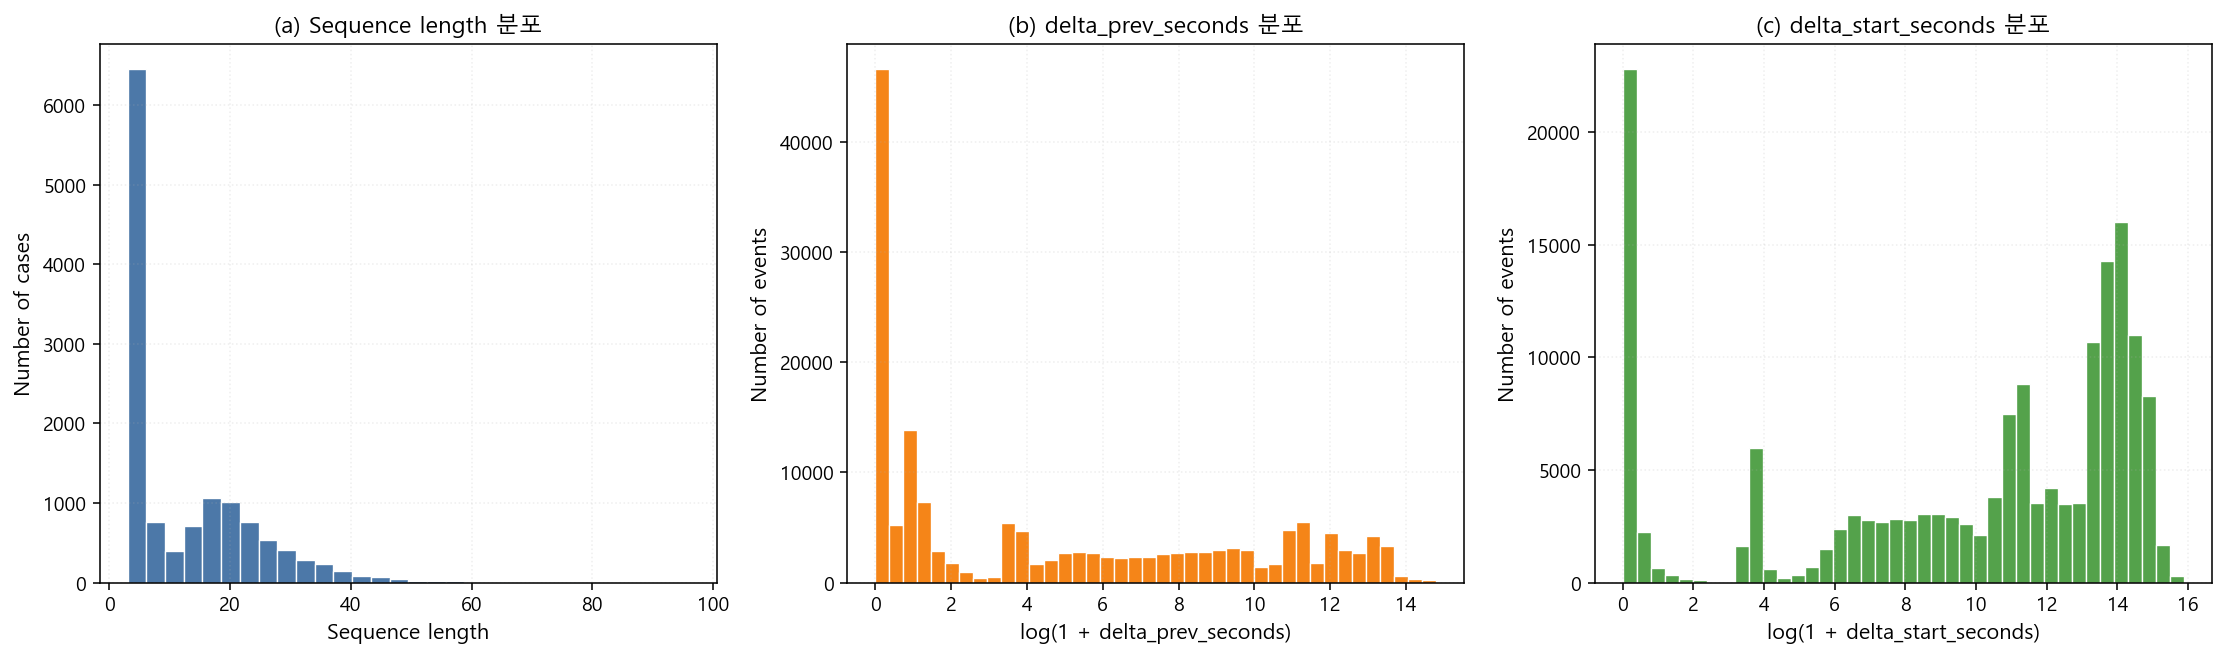

C:\Users\hyewoo choi\Documents\99. 대학원\0. 논문\git\time-aware-behavior-prediction\outputs\report_figures\figure2_distributions_stage3_v2.png
C:\Users\hyewoo choi\Documents\99. 대학원\0. 논문\git\time-aware-behavior-prediction\outputs\report_figures\figure2_distributions_stage3_v2.pdf


In [3]:
seq_values = case_lengths.to_numpy()
delta_prev = df["delta_prev_seconds"].to_numpy(dtype=float)
delta_start = df["delta_start_seconds"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].hist(seq_values, bins=30, color="#4C78A8", edgecolor="white", linewidth=0.7)
axes[0].set_title("(a) Sequence length \ubd84\ud3ec")
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("Number of cases")
axes[0].grid(alpha=0.2, linestyle=":")

axes[1].hist(np.log1p(delta_prev), bins=40, color="#F58518", edgecolor="white", linewidth=0.7)
axes[1].set_title("(b) delta_prev_seconds \ubd84\ud3ec")
axes[1].set_xlabel("log(1 + delta_prev_seconds)")
axes[1].set_ylabel("Number of events")
axes[1].grid(alpha=0.2, linestyle=":")

axes[2].hist(np.log1p(delta_start), bins=40, color="#54A24B", edgecolor="white", linewidth=0.7)
axes[2].set_title("(c) delta_start_seconds \ubd84\ud3ec")
axes[2].set_xlabel("log(1 + delta_start_seconds)")
axes[2].set_ylabel("Number of events")
axes[2].grid(alpha=0.2, linestyle=":")

fig.tight_layout()

png_path = OUTPUT_DIR / "figure2_distributions_stage3_v2.png"
pdf_path = OUTPUT_DIR / "figure2_distributions_stage3_v2.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(png_path)
print(pdf_path)


In [4]:
single_dir = OUTPUT_DIR / "figure2_panels"
single_dir.mkdir(parents=True, exist_ok=True)

panel_specs = [
    ("sequence_length_distribution.png", seq_values, 30, "#4C78A8", "Sequence length", "Number of cases", "(a) Sequence length \ubd84\ud3ec"),
    ("delta_prev_distribution_log1p.png", np.log1p(delta_prev), 40, "#F58518", "log(1 + delta_prev_seconds)", "Number of events", "(b) delta_prev_seconds \ubd84\ud3ec"),
    ("delta_start_distribution_log1p.png", np.log1p(delta_start), 40, "#54A24B", "log(1 + delta_start_seconds)", "Number of events", "(c) delta_start_seconds \ubd84\ud3ec"),
]

for filename, values, bins, color, xlabel, ylabel, title in panel_specs:
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    ax.hist(values, bins=bins, color=color, edgecolor="white", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2, linestyle=":")
    fig.tight_layout()
    fig.savefig(single_dir / filename, bbox_inches="tight")
    plt.close(fig)

single_dir


WindowsPath('C:/Users/hyewoo choi/Documents/99. 대학원/0. 논문/git/time-aware-behavior-prediction/outputs/report_figures/figure2_panels')